In [39]:
import torch.nn as nn
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from utils import *
from torch.utils.data import DataLoader
from models import *
import random
from collections import Counter
from collections import OrderedDict
import seaborn as sns
import copy

cos = nn.CosineSimilarity(dim=0, eps=1e-9)
device = "cuda"

# study 1 model's training with the new loss function with dist limits

# adjustable parameters
alpha_d = 100 # IID
local_ep = 5 
n_clients = 10 # dataset size for one client
mali_local_ep = 5
global attack 
attack = "untargeted" #"backdoor", "tlp", "ut"
model_name = "resnet8" # "resnet8", "ConvNet", "MLP"
num_classes = 10
dataset ="cifar10" # "cifar10", "fmnist"

In [40]:
def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}

# # Example usage
# model = nn.Sequential(
#     nn.Linear(10, 5),
#     nn.BatchNorm1d(5),  # This has buffers (running_mean, running_var) in state_dict but not in parameters
#     nn.Linear(5, 2)
# )

# filtered_state_dict = filter_trainable_state_dict(model)
# print(filtered_state_dict.keys())  # Only includes trainable parameters


In [41]:
def cos_dist(w1, w2):
    """Compute cosine similarity between two flattened weight tensors"""
    w1_flat, w2_flat = torch.cat([p.view(-1) for p in w1]), torch.cat([p.view(-1) for p in w2])
    return 1 - torch.dot(w1_flat, w2_flat) / (torch.norm(w1_flat) * torch.norm(w2_flat))


def restore_dict_w_flat(param_flat, model_dict):
    restored_w = {}
    start = 0
    for name, param in model_dict.items():
            num_elements = param.numel()
            restored_w[name] = param_flat[start:start + num_elements].view(param.shape)                          
            start += num_elements
    return restored_w

def model_eval(model, test_loader, attack):
    acc = eval_op_ensemble([model], test_loader)
    if attack == "tlp":
        asr = eval_op_ensemble_tr_lf_attack([model], test_loader)
    elif attack == "backdoor":
        asr = eval_op_ensemble_attack([model], test_loader)
    elif attack == "untargeted":
        asr = None
    return list(acc.values())[0], list(asr.values())[0]


def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}


def train_rev_w_cos(model, loader, optimizer, scheduler, epochs, model0, model1, beta, budget):    
    model.train()
    # model.parameters need to use 
    flat_model0 = flat_dict(filter_trainable_state_dict(model0))
    flat_model1 = flat_dict(filter_trainable_state_dict(model1))
    
    losses = []
    running_loss, samples = 0.0, 0
    print(f"data length {len(loader) * loader.batch_size}: batches {len(loader)}, batch_size {loader.batch_size}")
    
    last_mail_w = flat_model0.clone().detach()
    for ep in range(epochs):
        for it, (x, y) in enumerate(loader):
            if it % 2 == 0:
                losses.append(round(eval_epoch(model, loader), 2))
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            # 1 negative CE loss
            loss_ce = nn.CrossEntropyLoss(reduction="mean")(model(x), y)
            loss_oppo_ce = - loss_ce

            running_loss += loss_oppo_ce.item() * y.shape[0]
            samples += y.shape[0]
            
            # add cos loss 
            w = torch.cat([p.view(-1) for p in model.parameters()]).to(device)
            target = torch.ones(len(w)).to(device)
            loss_cos = nn.CosineEmbeddingLoss()(flat_model0.unsqueeze(0), w.unsqueeze(0), target)
            
            # combindation loss
            loss_obj = (1-beta) * loss_oppo_ce + beta * loss_cos
            # only negative loss
            # loss_obj = loss_oppo_ce 
            
            loss_obj.backward()
            optimizer.step()
            scheduler.step()
            if it % 5 == 0:
                print(f"ep{ep}, loss_ce: {loss_oppo_ce:.2f}, loss_cos: {loss_cos:.6f}, loss_obj: {loss_obj:.2f}, lr: {optimizer.param_groups[0]['lr']}")
        
        # break
        crafted_cos_d = cos_dist_w(flat_model0, w)
        print(f"cos_d: {crafted_cos_d}, budget: {budget}")

        if crafted_cos_d > budget:
            print(f"budget exceeded, finish training early, ep = {ep}")
            break
        
        last_mail_w = w
        
    # craft_g = combine_tensors(B=grad_ben, M=grad_mail, budget=budget)
    craft_w = craft_tensor(B=flat_model0, M1=last_mail_w, M2=w, k=budget)
    
    # restored_crafted = restore_dict_grad_flat(craft_w, model0.state_dict(), model.state_dict())
    restored_crafted = restore_dict_w_flat(craft_w, model.state_dict())
    model.load_state_dict(restored_crafted)
    crafted_cos_d = cos_dist_w(flat_model0, craft_w)
        
    print(f"crafted cos_d: {crafted_cos_d}")        

    return {"loss": running_loss / samples}
    

In [42]:
# Define transformation (convert images to tensors and normalize)
transform_img = T.Compose([
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize the image with mean and std
])

if dataset == "fmnist":
    # Load the training dataset
    train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_img)
    # Load the test dataset
    test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_img)
elif dataset == "cifar10":
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_img)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_img)

# Create DataLoader for batch processing
client_loaders, test_loader, client_data_subsets =\
    data.get_loaders(train_data, test_data, n_clients,
                    alpha=alpha_d, batch_size=32, n_data=None, num_workers=4, seed=4)
    
model_fn = partial(models.get_model(model_name)[
                        0], num_classes=num_classes, dataset=dataset)

client_loader = client_loaders[0]

# created models 
model0 = model_fn().to(device) # orginal model
model1 = model_fn().to(device) # train with clean data
model2 = model_fn().to(device) # train with new loss function
model3 = model_fn().to(device)

model0_sd = {k: v.clone().detach() for k, v in model1.state_dict().items()}

optimizer0 = optim.SGD(model0.parameters(), lr=0.001)
optimizer1 = optim.SGD(model1.parameters(), lr=0.001)

optimizer3 = optim.SGD(model3.parameters(), lr=0.001)



100%|██████████| 170M/170M [00:44<00:00, 3.83MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Data split:
 - Client 0: [511 445 449 449 564 501 594 528 483 470]               -> sum=4994
 - Client 1: [529 512 541 490 484 466 503 541 513 423]               -> sum=5002
 - Client 2: [473 554 504 527 462 480 435 564 507 493]               -> sum=4999
 - Client 3: [544 503 544 501 514 482 531 474 497 410]               -> sum=5000
 - Client 4: [477 497 428 478 430 515 507 540 552 576]               -> sum=5000
 - Client 5: [451 463 525 472 487 546 499 525 479 553]               -> sum=5000
 - Client 6: [512 574 475 536 430 557 458 450 465 542]               -> sum=4999
 - Client 7: [467 462 584 470 618 495 444 454 512 495]               -> sum=5001
 - Client 8: [527 456 530 482 523 480 511 468 455 569]               -> sum=5001
 - Client 9: [509 534 420 595 488 478 518 456 537 469]               -> sum=5004
 - Total:     [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]



In [43]:
# model1 train benign
train_op(model1, client_loader, optimizer1, epochs=3, print_train_loss=True)



KeyboardInterrupt: 

In [ ]:
model1_sd = {key: value.clone() for key, value in model1.state_dict().items()}

model1_result = eval_op_ensemble([model1], test_loader)
print("model1_result", model1_result)

model1_result {'test_accuracy': 0.2374}


In [ ]:
def mali_model_craft_w_budget(model2, client_loader, budget):
    # model2 train with new loss function
    optimizer2 = optim.SGD(model2.parameters(), lr=0.0001) # 0.001
    scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=1)

    model2.load_state_dict(model1_sd)
    model2_result_before = eval_op_ensemble([model2], test_loader)
    
    train_rev_w_cos(model2, client_loader, optimizer2, scheduler2, epochs=4, 
                                    model0 = model0, 
                                    model1 = model1, 
                                    beta = 0.5, 
                                    budget = budget)
    
    cos_d = cos_dist(flat_dict(filter_trainable_state_dict(model1)),
                         flat_dict(filter_trainable_state_dict(model2)))
    
    model2_result = eval_op_ensemble([model2], test_loader)
    
    return cos_d, model2_result, model2_result_before 

In [9]:
mali_model_craft_w_budget(model2, client_loader, budget=0.001)

data length 608: batches 19, batch_size 32
ep0, loss_ce: -1.22, loss_cos: 0.260273, loss_obj: -0.92, lr: 0.0001
ep0, loss_ce: -1.22, loss_cos: 0.260273, loss_obj: -0.92, lr: 0.0001
ep0, loss_ce: -1.29, loss_cos: 0.260273, loss_obj: -0.98, lr: 0.0001
ep0, loss_ce: -1.28, loss_cos: 0.260272, loss_obj: -0.97, lr: 0.0001
cos_d: 0.26027214527130127, budget: 0.001
budget exceeded, finish training early, ep = 0
alpha_tensor tensor(0.9348)
crafted cos_d: 0.0009999871253967285


(tensor(0.2309, device='cuda:0'),
 {'test_accuracy': 0.0209},
 {'test_accuracy': 0.7005})

## if norm are the same

In [13]:
flat_grad_benign = flat_dict(filter_trainable_state_dict(model1)) - flat_dict(filter_trainable_state_dict(model0))
flat_grad_mali = flat_dict(filter_trainable_state_dict(model2)) - flat_dict(filter_trainable_state_dict(model0))

torch.norm(flat_grad_mali, p=2)

tensor(1.0736, device='cuda:0')

In [14]:
# flat_grad_mali = flat_grad_mali / torch.norm(flat_grad_mali, p=2) * torch.norm(flat_grad_benign, p=2) 
torch.norm(flat_grad_benign, p=2), torch.norm(flat_grad_mali, p=2)

(tensor(16.4692, device='cuda:0'), tensor(1.0736, device='cuda:0'))

In [67]:
r_w = restore_dict_grad_flat(flat_grad_mali, model0.state_dict(), model0.state_dict())

In [74]:
model2.load_state_dict(r_w)

<All keys matched successfully>

In [79]:
eval_op_ensemble([model2], test_loader)

{'test_accuracy': 0.0828}

## series experiments

In [47]:
# budgets = np.linspace(1e-7, 1e-3, 10)
budgets = np.logspace(np.log10(5e-7), np.log10(0.01), 5)
budgets

array([5.00000000e-07, 5.94603558e-06, 7.07106781e-05, 8.40896415e-04,
       1.00000000e-02])

In [48]:
results = {}
for b in budgets:
    cos_d, model2_result, model2_result_before = mali_model_craft_w_budget(model2, client_loader, b)
    print("cos_d, model2_result", cos_d, model2_result)
    results[float(b)] = (cos_d.item(), list(model2_result.values())[0])

data length 608: batches 19, batch_size 32
ep0, loss_ce: -1, loss_cos: 0.2602, loss_obj: -1, lr: 0.005
ep0, loss_ce: -2, loss_cos: 0.2602, loss_obj: -1, lr: 0.005
cos_d: 0.26015567779541016, budget: 5e-07
budget exceeded, finish training early, ep = 0
alpha_tensor tensor(0.9985)
crafted cos_d: 4.76837158203125e-07
cos_d, model2_result tensor(0.2595, device='cuda:0') {'test_accuracy': 0.1046}
data length 608: batches 19, batch_size 32
ep0, loss_ce: -1, loss_cos: 0.2602, loss_obj: -1, lr: 0.005
ep0, loss_ce: -2, loss_cos: 0.2602, loss_obj: -1, lr: 0.005


KeyboardInterrupt: 

In [1]:
results

NameError: name 'results' is not defined

In [21]:

cos_d_model1_2 = cos_dist(flat_dict(model1.state_dict()) - flat_dict(model0.state_dict()), 
                          flat_dict(model2.state_dict()) - flat_dict(model0.state_dict()))
print("model1_2 cos dist", cos_d_model1_2)



model1_2 cos dist tensor(0.0001, device='cuda:0')


In [1]:
# visualization of the layers

import torch
import numpy as np
import matplotlib.pyplot as plt

def compare_model_weights(model1, model2):
    """
    Compare the weights of two PyTorch models layer by layer using bar charts.
    
    Args:
        model1 (torch.nn.Module): The first model to compare.
        model2 (torch.nn.Module): The second model to compare.
    
    Returns:
        None (displays a bar chart of L2 distance and cosine dissimilarity).
    """
    layer_names = []
    l2_distances = []
    cos_dissimilarities = []
    
    for (name1, param1), (name2, param2) in zip(model1.named_parameters(), model2.named_parameters()):
        if name1 != name2:
            raise ValueError(f"Layer mismatch: {name1} vs {name2}")
        
        layer_names.append(name1)
        param1_flat = param1.view(-1)
        param2_flat = param2.view(-1)
        
        l2_distance = torch.norm(param1_flat - param2_flat, p=2).item()
        l2_distances.append(l2_distance)
        
        cos_sim = torch.nn.functional.cosine_similarity(param1_flat, param2_flat, dim=0).item()
        cos_dissimilarities.append(1 - cos_sim)
    
    
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    flat_grad_model2 = flat_dict(filter_trainable_state_dict(model2))
    layer_names.append("all")
    
    l2_distance = torch.norm(flat_grad_model1 - flat_grad_model2, p=2).item()
    l2_distances.append(l2_distance)
        
    cos_sim = torch.nn.functional.cosine_similarity(flat_grad_model1, flat_grad_model2, dim=0).item()
    cos_dissimilarities.append(1 - cos_sim)
    
    # Plot results as bar charts
    x = np.arange(len(layer_names))  # Layer indices
    width = 0.35  # Width of the bars

    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Bar chart for L2 Distance
    ax1.bar(x - width/2, l2_distances, width, label="L2 Distance", color='tab:blue')
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("L2 Distance", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Bar chart for Cosine Dissimilarity
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, cos_dissimilarities, width, label="Cos Disimilarity", color='tab:red')
    ax2.set_ylabel("Cos Disimilarity", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)
    
    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    # Add title and layout adjustments
    plt.title("Layer-wise L2 Distance and Cosine Dissimilarity (Bar Chart)")
    # fig.tight_layout()
    plt.show()

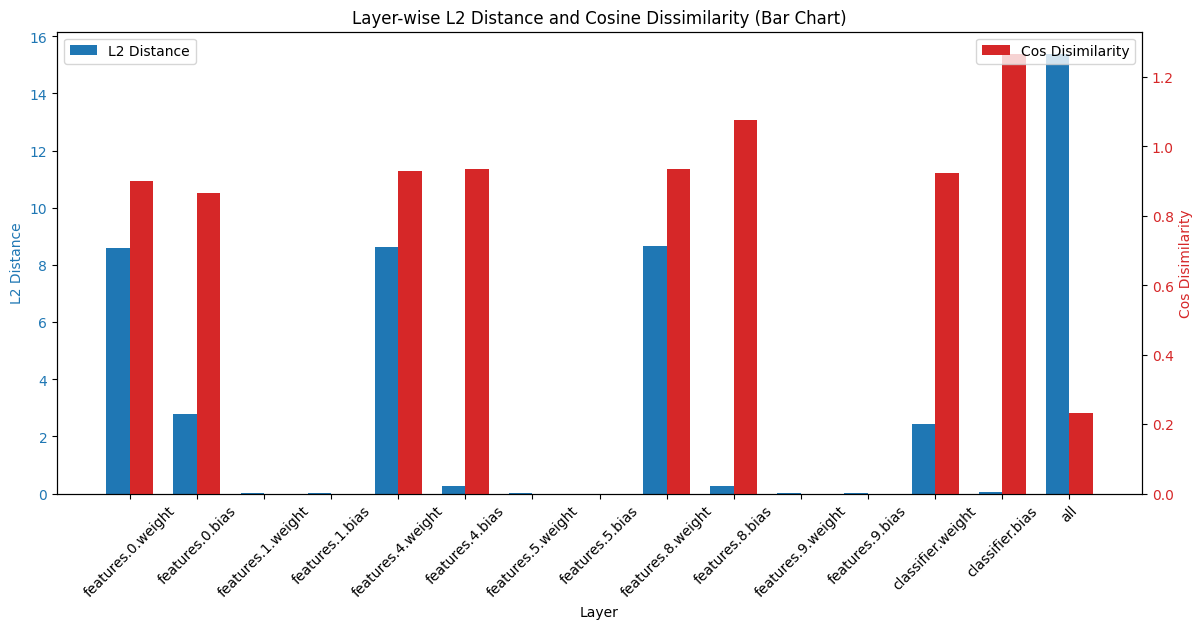

In [12]:
compare_model_weights(model1, model2)

The L2 and Cosine distince is small in this attack

In [16]:
import torch.nn as nn

# Example model
model = nn.Sequential(
    nn.Linear(10, 5),
    nn.BatchNorm1d(5),  # This has buffers (running_mean, running_var) in state_dict but not in parameters
    nn.Linear(5, 2)
)

# Get parameter names (those in model.parameters())
param_names = {name for name, param in model.named_parameters()}

# Filter state_dict keys that are in param_names
filtered_state_dict = {k: v for k, v in model.state_dict().items() if k in param_names}

# Display results
print(filtered_state_dict.keys())  # Only includes layers that are in model.parameters()


dict_keys(['0.weight', '0.bias', '1.weight', '1.bias', '2.weight', '2.bias'])


In [17]:
import torch
import torch.nn.functional as F

# Define a reference tensor X
X = torch.tensor([1.0, 2.0, 3.0])

# Construct two different tensors A and B that are not scalar multiples but have the same cosine similarity to X
A = torch.tensor([2.0, 0.0, 1.0])  
B = torch.tensor([1.0, 3.0, 0.0])  

# Compute cosine similarities
cos_sim_A = F.cosine_similarity(A.unsqueeze(0), X.unsqueeze(0), dim=1)
cos_sim_B = F.cosine_similarity(B.unsqueeze(0), X.unsqueeze(0), dim=1)

print(f"Cosine similarity of A and X: {cos_sim_A.item()}")
print(f"Cosine similarity of B and X: {cos_sim_B.item()}")


Cosine similarity of A and X: 0.5976142883300781
Cosine similarity of B and X: 0.591607928276062


In [18]:
import torch
import torch.nn.functional as F

def cosine_distance(x, y):
    # Compute cosine distance between two tensors
    return 1 - F.cosine_similarity(x, y, dim=-1)

def craft_tensor(B, M1, M2, k):
    # Compute cosine distances
    d_cos_B_M1 = cosine_distance(B, M1)
    d_cos_B_M2 = cosine_distance(B, M2)
    
    # Check conditions
    if d_cos_B_M2 > k and d_cos_B_M1 < k:
        # Find the weight alpha such that cos(B, C) = k
        # C = alpha * M1 + (1 - alpha) * M2
        # We need to solve for alpha such that cosine_distance(B, C) = k
        
        # Define a function to compute the cosine distance between B and C
        def objective(alpha):
            C = alpha * M1 + (1 - alpha) * M2
            return cosine_distance(B, C) - k
        
        # Use a numerical solver to find alpha
        from scipy.optimize import fsolve
        alpha_initial_guess = 0.5
        alpha = fsolve(objective, alpha_initial_guess)[0]
        
        # Craft the new tensor C
        C = alpha * M1 + (1 - alpha) * M2
        return C
    else:
        # If conditions are not met, return None or handle accordingly
        return None

# Example usage
B = torch.tensor([1.0, 0.0, 0.0])
M1 = torch.tensor([0.8, 0.2, 0.0])
M2 = torch.tensor([0.0, 0.0, 1.0])
k = 0.5

C = craft_tensor(B, M1, M2, k)
print(C)

TypeError: unsupported operand type(s) for *: 'numpy.ndarray' and 'Tensor'

In [ ]:
import torch
a = torch.tensor([1.0, 2.0, 3.0])

In [ ]:
a * 3

tensor([3., 6., 9.])

In [ ]:
import torch
import torch.nn.functional as F

class OppositeCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class

        correct_mask = (preds != targets).float()  # Mask where predictions are correct
        loss = - correct_mask * torch.log(probs[torch.arange(len(targets)), targets] + 1e-10)  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = OppositeCrossEntropyLoss()
logits = torch.tensor([[2.0, 1.0], [0.5, 1.5]])  # Model output (logits)
targets = torch.tensor([1, 0])  # True labels
loss = criterion(logits, targets)
print(loss)


tensor(1.3133)


In [ ]:
class ReverseCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class
        
        correct_mask = (preds == targets).float()  # Mask where predictions are correct
        loss = correct_mask * (-torch.log(1 - probs[torch.arange(len(targets)), targets] + 1e-10))  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = ReverseCrossEntropyLoss()
loss = criterion(logits, targets)
print(loss)

tensor(0.)


In [ ]:
import torch
import torch.nn.functional as F

class ReverseCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class
        
        correct_mask = (preds == targets).float()  # Mask where predictions are correct
        loss = correct_mask * (-torch.log(1 - probs[torch.arange(len(targets)), targets] + 1e-10))  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = ReverseCrossEntropyLoss()
logits = torch.tensor([[0.0, 1.0], [0.5, 1.5]])  # Model output (logits)
targets = torch.tensor([0, 1])  # True labels
loss = criterion(logits, targets)
print(loss)


tensor(0.6566)


In [ ]:
a = {"a":1, "b":2, "c":3}

In [ ]:
a.values()

dict_values([1, 2, 3])

In [ ]:
for p in a.values():
    print(p)

1
2
3


In [ ]:
import torch.nn as nn
loss = nn.BCEWithLogitsLoss()
input = torch.randn(3, requires_grad=True)
target = torch.empty(3).random_(2)
output = loss(input, target)
output.backward()

In [ ]:
m = nn.Softmax(dim=0)
input = torch.randn(10)
output = m(input)
output

tensor([0.0303, 0.0065, 0.0311, 0.1110, 0.0261, 0.5034, 0.0473, 0.0147, 0.0566,
        0.1729])